### To test correlations between HEXACO lexical analysis scores and HEXACO-PI-R 100 scores.

i.e. 

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import numpy as np

# scores_data contains the scores returned from the lexical survey (1702x310)
# i.e. how the agents rated themselves on each adjective.
scores_file = 'data/popc_results.csv'
scores_data = pd.read_csv(scores_file, index_col=0)
to_fix = [x for x in scores_data.index if "'" in x]
print(f'Fixing names: {", ".join(to_fix)}.')
for n in to_fix:
    scores_data.rename(index={n:n.replace("'", '')}, inplace=True)
print(f"Read in {len(scores_data)} responses from {scores_file}")

# agent_loadings contains the weights for each of the 10 pca-derived factors
# i.e. how much each adjective contributes to each factor.
agent_loadings = pd.read_csv('intermediate/loadings_popc_10.csv', index_col=0)
agent_loadings.columns = ['Dishonesty',
                          'Disagreeableness',
                          'Introversion',
                          'Unconscientiousness',
                          'Unheroic',
                          'Unscholarly',
                          'Gendered-emotionality',
                          'Unsentimentality',
                          'Insensitivity',
                          'Unartistic']

Fixing names: PatrickO'Connor, Margaret'Maggie'Dupont, MartinO'Donnell, Johnathan'BigJohn'Moretti, JohnO'Reilly.
Read in 310 responses from data/popc_results.csv


In [2]:
# calculate scores for each agent, based on the recovered factors' loadings.
df_dimensions = pd.DataFrame(index=scores_data.index)
for factor in agent_loadings.columns:
    terms = list(agent_loadings[factor].dropna().index)
    weights = agent_loadings[factor].dropna()
    scores = [x-5 for x in scores_data[terms].values]
    scores = np.array(scores)
    scores = scores * weights.values
    df_dimensions[factor] = scores.sum(axis=1)
    
df_dimensions[:5]

,Dishonesty,Disagreeableness,Introversion,Unconscientiousness,Unheroic,Unscholarly,Gendered-emotionality,Unsentimentality,Insensitivity,Unartistic
DaveThomas,-187.801466,157.643697,34.223071,-471.683534,-58.906754,-119.082854,-111.048052,31.585243,-43.596766,5.739249
OliverHarris,-200.566474,190.108360,-62.893161,-396.595915,-114.461764,-103.182884,-26.907505,-73.786820,-97.946922,2.369920
DavidHarrison,-185.919976,-56.309447,-26.633121,-489.013335,38.008888,-190.746573,-97.649288,7.145955,7.086425,-38.082949
JerryMcAlister,299.266586,-57.928586,-278.533774,-247.742093,-327.966392,-106.208720,-81.729967,57.190520,37.768405,-93.513383
GregoryHarrison,81.601540,54.534997,173.808648,-480.600928,-64.183731,-208.497500,-124.469778,92.652522,29.369394,-20.142104


### Comparing lexical 'scores' against GPT-4 HEXACO-PI-R 100 scores.

In [3]:
def get_pir_scores(file):
    """
    Reads in the HEXACO-PI-R scores from a CSV file and returns the scores.
    """

    # now load in the scores from the HEXACO-PI-R 100 survey.
    from support.hexaco_pi_r import responses_to_scores, scoring, calc_dimension_scores
    pir100 = pd.read_csv(file, index_col=0)
    print(f"Read in {len(pir100)} sets of survey responses (questions={pir100.shape[1]}), from {file}.")
    pir100.rename(index={'CalebJThompson':'CalebJ'}, inplace=True)
    pir100.rename(index={'JohnathonKRiley':'JohnathonK'}, inplace=True)
    pir100.rename(index={'VioletBRichmond':'VioletB'}, inplace=True)
    pir100.columns = range(len(pir100.columns))

    # map text responses to score, using scoring mechanism (includes reverse scoring)
    pir100_scores = responses_to_scores(pir100, scoring)

    # then figure out a score for each dimension for each agent.
    pir100_dim_scores = calc_dimension_scores(pir100_scores, scoring)
    return pir100_dim_scores
    
df = get_pir_scores("data/hexaco-pi-r-responses-GPT-4.csv")
df[:5]

Read in 310 sets of survey responses (questions=100), from data/hexaco-pi-r-responses-GPT-4.csv.


,Honesty-Humility,Emotionality,Extraversion,Agreeableness,Conscientiousness,Openness
DaveThomas,4.125,2.5625,3.125,2.5625,4.9375,3.0
OliverHarris,4.375,3.25,3.75,2.5,4.875,3.6875
DavidHarrison,4.0625,2.0625,3.75,3.125,4.9375,3.375
JerryMcAlister,2.75,2.75,4.3125,2.625,4.5,3.0
GregoryHarrison,3.5625,2.375,3.125,2.625,4.75,3.3125


In [4]:
def calc_pearsons(df_dimensions, pir100_dim_scores):
    """
    Calculates the Pearson correlation coefficients between the dimensions
    in df_dimensions and the HEXACO-PI-R scores in pir100_dim_scores.
    Returns a DataFrame with the results.
    """
    from scipy.stats import pearsonr

    # now select the best 6 factors (semantic similarity with hexaco)
    # to match the 6 hexaco factors.
    selection_df = df_dimensions.copy()
    selection_df = selection_df[['Dishonesty', 'Gendered-emotionality', 
                                'Introversion', 'Disagreeableness', 
                                'Unconscientiousness', 'Unscholarly']]
    selection_df.columns = ['Honesty-Humility', 'Emotionality', 
                            'Extraversion', 'Agreeableness', 
                            'Conscientiousness', 'Openness']

    results_df = pd.DataFrame(index=selection_df.columns)
    for dim in selection_df.columns:
        r, p_value = pearsonr(selection_df[dim], pir100_dim_scores[dim])
        results_df.loc[dim, 'r'] = r
        results_df.loc[dim, 'p_value'] = p_value

    results_df = results_df.round(3)
    results_df.columns = ['r', 'p']
    return results_df

calc_pearsons(df_dimensions, df)

,r,p
Honesty-Humility,-0.814,0.0
Emotionality,0.686,0.0
Extraversion,-0.833,0.0
Agreeableness,-0.873,0.0
Conscientiousness,-0.934,0.0
Openness,-0.447,0.0


### Now display the results for all 4 models' pir results, against agent (lexical) scores.

In [5]:
files = {"GPT-4": "data/hexaco-pi-r-responses-GPT-4.csv",
         "Sonnet": "data/hexaco-pi-r-responses-sonnet.csv",
         "Phi4": "data/hexaco-pi-r-responses-phi4.csv",
         "Llama3.2": "data/hexaco-pi-r-responses-llama3.2.csv",
         }

table = pd.DataFrame(index=files.keys(), columns=['Honesty-Humility',
                                                    'Emotionality',
                                                    'Extraversion',
                                                    'Agreeableness',
                                                    'Conscientiousness',
                                                    'Openness'])

for name, file in files.items():
    df = get_pir_scores(file)
    results = calc_pearsons(df_dimensions, df)
    r_vals = [str(round(val, 3)) for val in results['r'].values]
    p_vals = ['p=' + str(round(val, 3)) for val in results['p'].values]
    zipped_vals = [f"{r} ({p})" for r, p in zip(r_vals, p_vals)]
    table.loc[name] = zipped_vals

table = table.round(3)
table.T

Read in 310 sets of survey responses (questions=100), from data/hexaco-pi-r-responses-GPT-4.csv.
Read in 310 sets of survey responses (questions=100), from data/hexaco-pi-r-responses-sonnet.csv.
Read in 310 sets of survey responses (questions=100), from data/hexaco-pi-r-responses-phi4.csv.
Read in 310 sets of survey responses (questions=100), from data/hexaco-pi-r-responses-llama3.2.csv.


,GPT-4,Sonnet,Phi4,Llama3.2
Honesty-Humility,-0.814 (p=0.0),-0.768 (p=0.0),-0.851 (p=0.0),-0.214 (p=0.0)
Emotionality,0.686 (p=0.0),0.734 (p=0.0),0.557 (p=0.0),0.117 (p=0.039)
Extraversion,-0.833 (p=0.0),-0.773 (p=0.0),-0.84 (p=0.0),-0.231 (p=0.0)
Agreeableness,-0.873 (p=0.0),-0.868 (p=0.0),-0.852 (p=0.0),-0.36 (p=0.0)
Conscientiousness,-0.934 (p=0.0),-0.928 (p=0.0),-0.896 (p=0.0),-0.368 (p=0.0)
Openness,-0.447 (p=0.0),-0.433 (p=0.0),-0.278 (p=0.0),-0.013 (p=0.819)


#### Plot the results for all of the 10 factors in the best solution, against the hexaco dimensions.

In [12]:
from scipy.stats import pearsonr

df = get_pir_scores("data/hexaco-pi-r-responses-GPT-4.csv")

# now for all hexaco dimensions, across all agent factors, report pearsons!   
results = pd.DataFrame(index=df.columns, columns=df_dimensions.columns)
for hexaco_survey in df.columns:
    for agents_factor in df_dimensions.columns:
        r, p_value = pearsonr(df[hexaco_survey], df_dimensions[agents_factor])
        results.loc[hexaco_survey, agents_factor] = r

pp = pd.DataFrame(results)
pp = pp.round(4)
pp

Read in 310 sets of survey responses (questions=100), from data/hexaco-pi-r-responses-GPT-4.csv.


,Dishonesty,Disagreeableness,Introversion,Unconscientiousness,Unheroic,Unscholarly,Gendered-emotionality,Unsentimentality,Insensitivity,Unartistic
Honesty-Humility,-0.814143,-0.185195,0.182002,-0.052862,0.359309,0.319759,0.019826,-0.49464,-0.466235,0.558512
Emotionality,-0.327795,-0.583673,-0.57309,0.350056,0.097236,-0.043447,0.686088,-0.527681,-0.659577,-0.16475
Extraversion,0.150988,-0.152745,-0.833114,0.339103,-0.674952,0.051593,0.226523,0.109329,0.30394,-0.511247
Agreeableness,-0.172876,-0.873091,-0.356763,0.43651,0.233616,-0.045804,0.349993,-0.509141,-0.112231,0.00505
Conscientiousness,0.101188,0.446421,0.384238,-0.934436,0.245543,-0.290447,-0.195238,0.189754,0.082279,-0.048806
Openness,0.026385,-0.328707,-0.140307,0.339341,-0.043974,-0.446625,0.377875,-0.309409,-0.350342,-0.385636


In [10]:
import seaborn as sns
sns.set_theme(style='white', font='Times New Roman')

/var/folders/58/2llpfv896kg760fpmknsz_lh0000gr/T/ipykernel_20607/2889501214.py:9: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annotations = results_numeric.applymap(lambda x: f"{'-' if x < 0 else ''}{abs(x):.2f}")


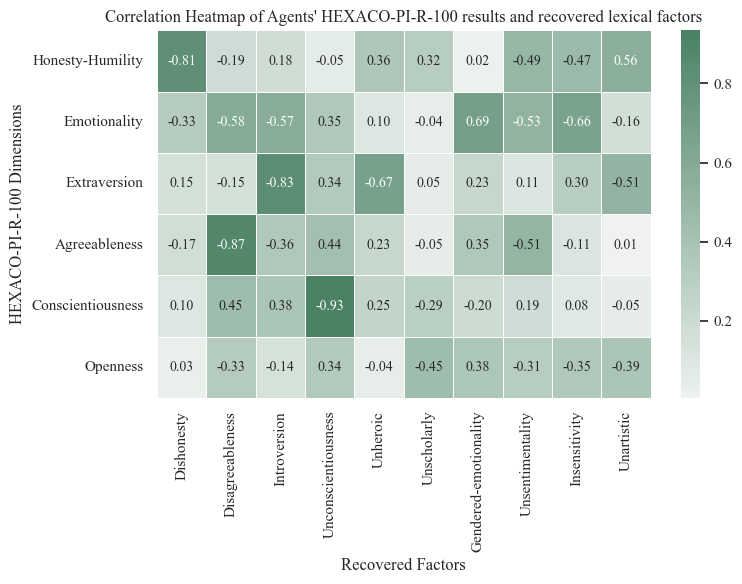

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Convert values to numeric type for heatmap visualization
results_numeric = results.astype(float)

# Create labels for annotations with absolute values and '-' for negative
annotations = results_numeric.applymap(lambda x: f"{'-' if x < 0 else ''}{abs(x):.2f}")

# Set the plot size
plt.figure(figsize=(8, 6))

# Create heatmap
cm = sns.diverging_palette(300, 145, s=60, as_cmap=True)
sns.heatmap(results_numeric.abs(), annot=annotations, fmt='', cmap=cm, center=0, linewidths=0.5, annot_kws={"size": 10})

# Add titles and labels
plt.title('Correlation Heatmap of Agents\' HEXACO-PI-R-100 results and recovered lexical factors')
plt.xlabel('Recovered Factors')
plt.ylabel('HEXACO-PI-R-100 Dimensions')

# Display the plot
plt.tight_layout()
plt.show()